In [1]:
print("E-Commerce Sales & Customer Analysis")

E-Commerce Sales & Customer Analysis


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("../data/Online Retail.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: '../data/Online Retail.xlsx'

In [4]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\ramir\OneDrive\Desktop\Ecommers-sales-customers-analysis\notebooks
['Ecommerce_sales_customers_analysis.ipynb']


In [5]:
df = pd.read_excel("../data/Online Retail.xlsx")

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("../data/Online Retail.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (541909, 8)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/cleaned_online_retail.csv",
    parse_dates=["InvoiceDate"]
)

print("Cleaned dataset loaded!")
print("Shape:", df.shape)

Cleaned dataset loaded!
Shape: (534129, 13)


In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.shape

(541909, 8)

In [8]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [10]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [11]:
df.dtypes


InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [12]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [13]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing

,Missing Count,Missing Percentage
InvoiceNo,0,0.000000
StockCode,0,0.000000
Description,1454,0.268311
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
CustomerID,135080,24.926694
Country,0,0.000000


## 6.1.1 Handling Missing Product Descriptions

Missing product descriptions are replaced with "Unknown" to preserve the transaction records.

In [1]:
df["Description"] = df["Description"].fillna("Unknown")

NameError: name 'df' is not defined

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("../data/Online Retail.xlsx")

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df["Description"] = df["Description"].fillna("Unknown")

In [9]:
df["Description"].isnull().sum()

np.int64(0)

## 6.2 Duplicate Record Analysis

Duplicate records are identified to prevent repeated transactions from affecting sales analysis.

In [23]:
df.duplicated().sum()

np.int64(0)

In [20]:
df[df.duplicated()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [22]:
df[df.duplicated()].shape

(0, 8)

### Removing Duplicate Records

Exact duplicate records are removed to prevent repeated transactions from affecting the analysis.

In [12]:
df = df.drop_duplicates()

In [13]:
df.shape

(536641, 8)

In [14]:
df.duplicated().sum()

np.int64(0)

## 6.3 Data Type Analysis

Data types are checked to ensure that each column is stored in an appropriate format for analysis and further processing.

In [27]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [26]:
df.info()

<class 'pandas.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    536641 non-null  object        
 1   StockCode    536641 non-null  object        
 2   Description  536641 non-null  object        
 3   Quantity     536641 non-null  int64         
 4   InvoiceDate  536641 non-null  datetime64[us]
 5   UnitPrice    536641 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      536641 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 43.8+ MB


## 6.3 Data Type Analysis

The data types of all columns were examined to ensure they are suitable for analysis. The dataset contains appropriate data types, with CustomerID stored as float because of missing values.

In [25]:
df[df["Quantity"] <= 0].shape

(10587, 8)

In [28]:
df[df["Quantity"] < 0].shape

(10587, 8)

In [29]:
df[df["Quantity"] == 0].shape

(0, 8)

In [30]:
df[df["Quantity"] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


### Identifying Cancellation Transactions

Negative quantities are associated with cancellation transactions. These records are separated from regular sales so that sales performance is not overstated or distorted.

In [31]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9251)

In [32]:
df[df["InvoiceNo"].astype(str).str.startswith("C")][
    ["InvoiceNo", "Quantity", "UnitPrice", "CustomerID"]
].head(10)

,InvoiceNo,Quantity,UnitPrice,CustomerID
141,C536379,-1,27.50,14527.0
154,C536383,-1,4.65,15311.0
235,C536391,-12,1.65,17548.0
236,C536391,-24,0.29,17548.0
237,C536391,-24,0.29,17548.0
238,C536391,-24,0.29,17548.0
239,C536391,-12,3.45,17548.0
240,C536391,-12,1.65,17548.0
241,C536391,-24,1.65,17548.0
939,C536506,-6,4.25,17897.0


In [3]:
df[(df["Quantity"] < 0) & 
   (~df["InvoiceNo"].astype(str).str.startswith("C"))].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


In [4]:
df[(df["Quantity"] < 0) & 
   (~df["InvoiceNo"].astype(str).str.startswith("C"))].shape

(1336, 8)

### Handling Invalid Transactions

Transactions with negative quantities and zero unit prices are excluded because they do not represent valid sales transactions.

In [5]:
df = df[~((df["Quantity"] < 0) & (df["UnitPrice"] == 0))]

In [6]:
df[df["Quantity"] < 0].shape

(9288, 8)

## 6.4 Unit Price Validation

UnitPrice values are checked for zero or negative values before calculating sales revenue.

In [7]:
df[df["UnitPrice"] <= 0].shape

(1181, 8)

In [8]:
df[df["UnitPrice"] <= 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
4348,536765,84952C,NaN,19,2010-12-02 14:43:00,0.0,NaN,United Kingdom


### Handling Invalid Unit Prices

Transactions with zero or negative unit prices are removed because they cannot contribute to valid sales revenue calculations.

In [9]:
df = df[df["UnitPrice"] > 0]

In [10]:
df[df["UnitPrice"] <= 0].shape

(0, 8)

In [11]:
df.shape

(539392, 8)

## 6.5 Revenue Calculation

Revenue is calculated by multiplying the quantity purchased by the unit price for each transaction.

In [12]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [13]:
df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [ ]:
## 6.6 Outlier Detection

Outliers are identified in numerical sales variables using the IQR method to detect unusually high or low values.

In [14]:
df[["Quantity", "UnitPrice", "Revenue"]].describe()

,Quantity,UnitPrice,Revenue
count,539392.000000,539392.000000,539392.000000
mean,9.845904,4.673648,18.112749
std,215.412652,94.614722,379.091706
min,-80995.000000,0.001000,-168469.600000
25%,1.000000,1.250000,3.750000
50%,3.000000,2.080000,9.840000
75%,10.000000,4.130000,17.400000
max,80995.000000,38970.000000,168469.600000


In [15]:
# Fill missing descriptions
df["Description"] = df["Description"].fillna("Unknown")

# Remove duplicate records
df = df.drop_duplicates()

# Keep only valid unit prices
df = df[df["UnitPrice"] > 0]

# Recalculate Revenue
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [16]:
df.shape

(534129, 9)

In [17]:
df.duplicated().sum()

np.int64(0)

## 6.6 Outlier Detection

Outliers are identified in numerical sales variables using the IQR method to understand unusually high or low transactions.

In [18]:
Q1 = df[["Quantity", "UnitPrice", "Revenue"]].quantile(0.25)
Q3 = df[["Quantity", "UnitPrice", "Revenue"]].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:")
print(lower_bound)

print("\nUpper Bound:")
print(upper_bound)

Lower Bound:
Quantity    -12.50
UnitPrice    -3.07
Revenue     -16.98
dtype: float64

Upper Bound:
Quantity     23.50
UnitPrice     8.45
Revenue      38.30
dtype: float64


In [19]:
outlier_counts = (
    (df[["Quantity", "UnitPrice", "Revenue"]] < lower_bound) |
    (df[["Quantity", "UnitPrice", "Revenue"]] > upper_bound)
).sum()

outlier_counts

Quantity     57326
UnitPrice    39448
Revenue      45114
dtype: int64

In [20]:
df.nlargest(10, "Revenue")[
    ["InvoiceNo", "StockCode", "Description",
     "Quantity", "UnitPrice", "Revenue", "CustomerID", "Country"]
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0,United Kingdom
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,15098.0,United Kingdom
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,NaN,United Kingdom
299982,A563185,B,Adjust bad debt,1,11062.06,11062.06,NaN,United Kingdom
173382,551697,POST,POSTAGE,1,8142.75,8142.75,16029.0,United Kingdom
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,17450.0,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,4992.00,14646.0,Netherlands


In [21]:
df.nlargest(10, "Quantity")[
    ["InvoiceNo", "StockCode", "Description",
     "Quantity", "UnitPrice", "Revenue", "CustomerID", "Country"]
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,1008.00,12901.0,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,3096.00,13135.0,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,3202.92,18087.0,United Kingdom
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,191.16,14609.0,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,0.32,960.00,16308.0,United Kingdom
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,0.18,518.40,16754.0,United Kingdom


## 6.7 Outlier Decision

The IQR method identified several extreme values in Quantity, UnitPrice, and Revenue. 
After inspecting the highest transactions, these values appear to represent genuine 
large or wholesale purchases rather than obvious data-entry errors. Therefore, 
the outliers are retained for further analysis.

## 6.8 Data Transformation

The InvoiceDate column is transformed into separate Year, Month, and Day columns
to support time-based sales analysis.

In [22]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day

In [23]:
df["Month_Year"] = df["InvoiceDate"].dt.to_period("M").astype(str)

In [24]:
df[["InvoiceDate", "Year", "Month", "Day", "Month_Year"]].head()

,InvoiceDate,Year,Month,Day,Month_Year
0,2010-12-01 08:26:00,2010,12,1,2010-12
1,2010-12-01 08:26:00,2010,12,1,2010-12
2,2010-12-01 08:26:00,2010,12,1,2010-12
3,2010-12-01 08:26:00,2010,12,1,2010-12
4,2010-12-01 08:26:00,2010,12,1,2010-12


In [25]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'Day',
       'Month_Year'],
      dtype='str')

In [3]:
df.to_csv("../data/cleaned_online_retail.csv", index=False)

In [4]:
import os

os.path.exists("../data/cleaned_online_retail.csv")

True

# 7. Exploratory Data Analysis (EDA)

EDA is performed to understand sales patterns, customer behavior, products, and countries using statistics and visualizations.

In [28]:
total_revenue = df["Revenue"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
total_products = df["StockCode"].nunique()

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)

Total Revenue: 9748131.07
Total Orders: 23796
Total Customers: 4371
Total Products: 3938


## 7.2 Monthly Revenue Trend

Monthly revenue is analyzed to identify sales trends and changes over time.

In [29]:
monthly_sales = df.groupby("Month_Year")["Revenue"].sum()

monthly_sales

Month_Year
2010-12     746723.610
2011-01     558448.560
2011-02     497026.410
2011-03     682013.980
2011-04     492367.841
2011-05     722094.100
2011-06     689977.230
2011-07     680156.991
2011-08     703510.580
2011-09    1017596.682
2011-10    1069368.230
2011-11    1456145.800
2011-12     432701.060
Name: Revenue, dtype: float64

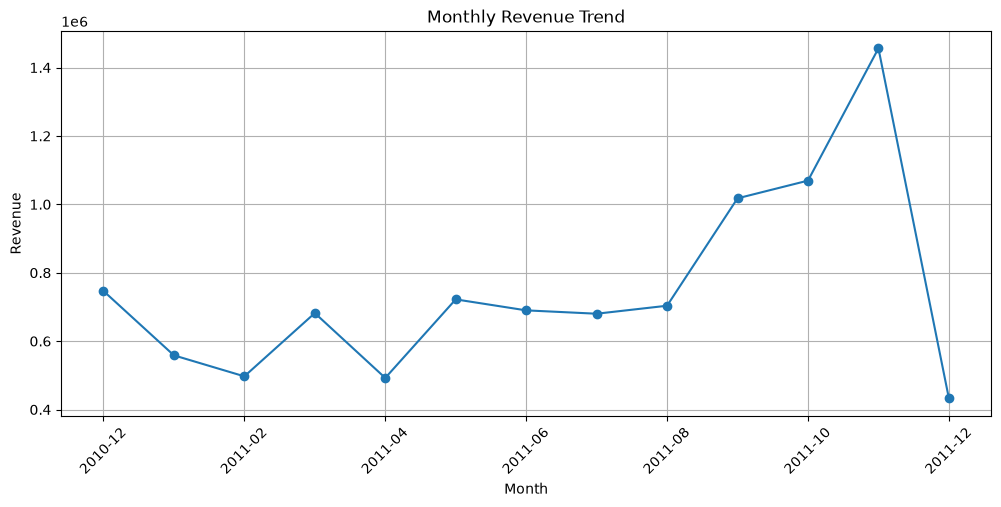

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## 7.3 Top 10 Products by Revenue

The top products are identified based on total revenue generated.

In [31]:
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164459.49
WHITE HANGING HEART T-LIGHT HOLDER     99612.42
PARTY BUNTING                          98243.88
JUMBO BAG RED RETROSPOT                92175.79
RABBIT NIGHT LIGHT                     66661.63
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63715.24
ASSORTED COLOUR BIRD ORNAMENT          58792.42
CHILLI LIGHTS                          53746.66
Name: Revenue, dtype: float64

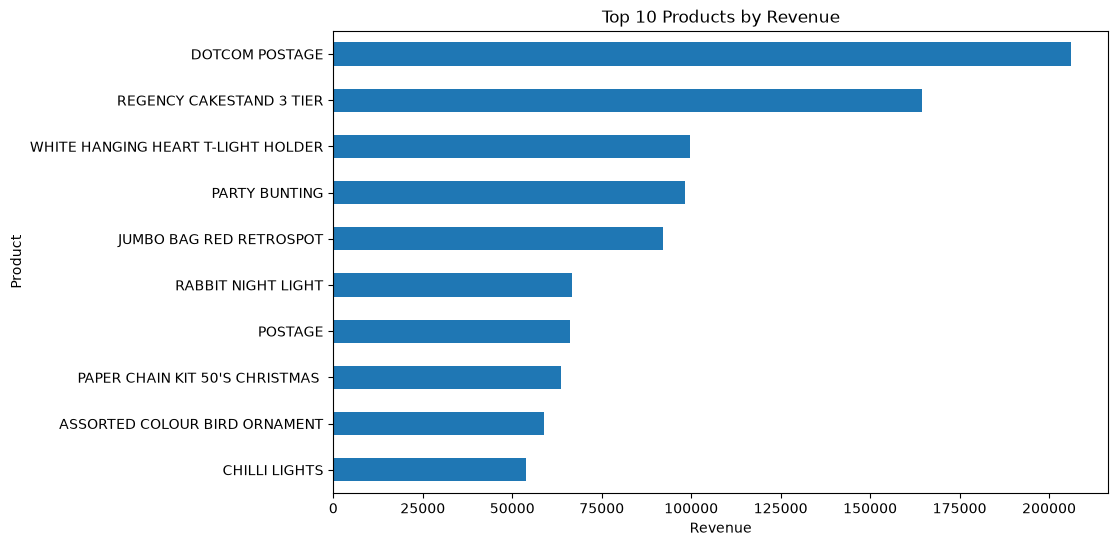

In [32]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

In [33]:
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

Country
United Kingdom    8189252.304
Netherlands        284661.540
EIRE               262993.380
Germany            221509.470
France             197317.110
Australia          137009.770
Switzerland         56363.050
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: Revenue, dtype: float64

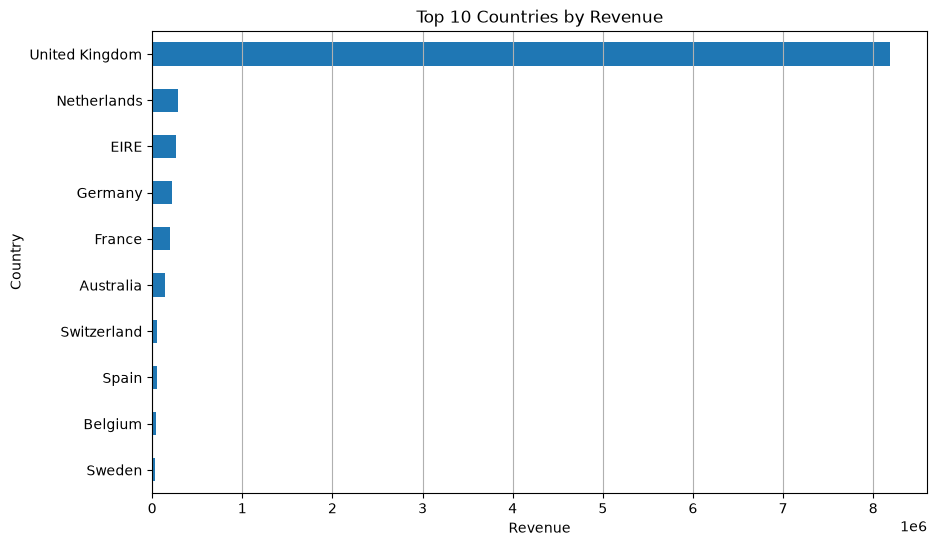

In [34]:
plt.figure(figsize=(10, 6))

country_revenue.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.grid(axis="x")

plt.show()

In [36]:
country_revenue.sort_values()

Country
Sweden              36585.410
Belgium             40910.960
Spain               54756.030
Switzerland         56363.050
Australia          137009.770
France             197317.110
Germany            221509.470
EIRE               262993.380
Netherlands        284661.540
United Kingdom    8189252.304
Name: Revenue, dtype: float64

In [37]:
country_revenue

Country
United Kingdom    8189252.304
Netherlands        284661.540
EIRE               262993.380
Germany            221509.470
France             197317.110
Australia          137009.770
Switzerland         56363.050
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: Revenue, dtype: float64

In [38]:
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164459.49
WHITE HANGING HEART T-LIGHT HOLDER     99612.42
PARTY BUNTING                          98243.88
JUMBO BAG RED RETROSPOT                92175.79
RABBIT NIGHT LIGHT                     66661.63
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63715.24
ASSORTED COLOUR BIRD ORNAMENT          58792.42
CHILLI LIGHTS                          53746.66
Name: Revenue, dtype: float64

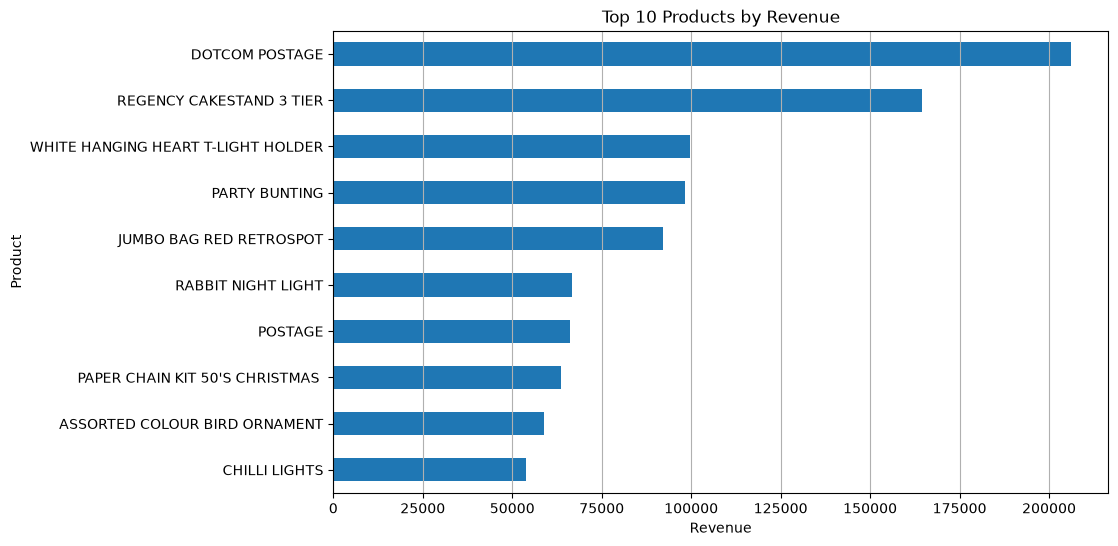

In [39]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.grid(axis="x")

plt.show()

In [40]:
customer_revenue = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

customer_revenue

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
14156.0    113214.59
17511.0     88125.38
16684.0     65892.08
13694.0     62690.54
15311.0     59284.19
Name: Revenue, dtype: float64

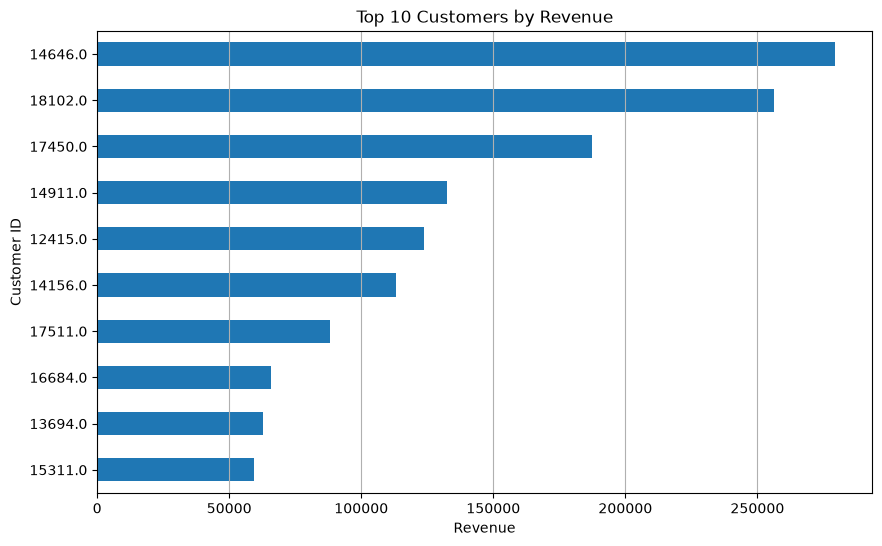

In [41]:
plt.figure(figsize=(10, 6))

customer_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.grid(axis="x")

plt.show()

In [42]:
customer_orders = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

customer_orders

CustomerID
14911.0    248
12748.0    223
17841.0    169
14606.0    128
13089.0    118
15311.0    118
12971.0     89
14527.0     86
13408.0     81
16029.0     76
Name: InvoiceNo, dtype: int64

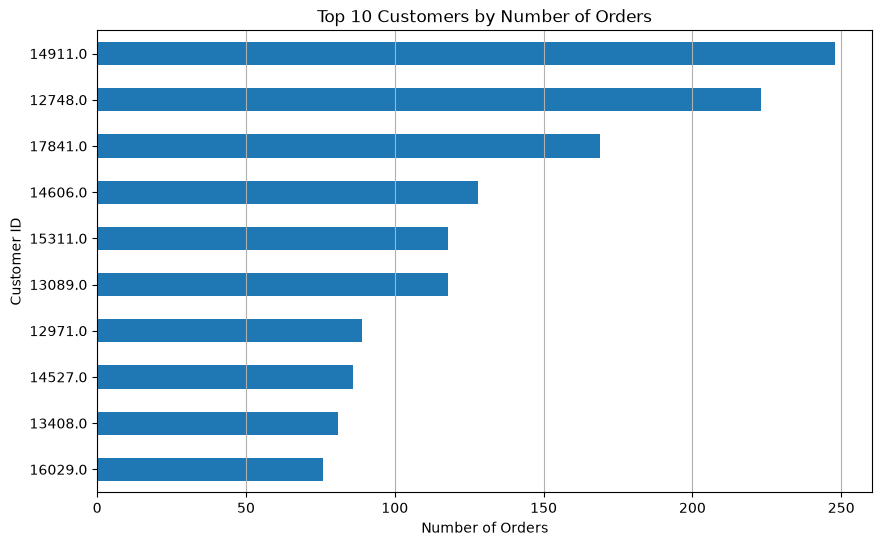

In [43]:
plt.figure(figsize=(10, 6))

customer_orders.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Customer ID")
plt.grid(axis="x")

plt.show()

## 7.5 Average Order Value

Average Order Value (AOV) measures the average revenue generated from each order.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/cleaned_online_retail.csv",
    parse_dates=["InvoiceDate"]
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.columns)

Dataset loaded successfully!
Shape: (541909, 8)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')


In [11]:
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Shape: (541909, 8)
Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [12]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print("Revenue column created successfully!")
print(df[["Quantity", "UnitPrice", "Revenue"]].head())

Revenue column created successfully!
   Quantity  UnitPrice  Revenue
0         6       2.55    15.30
1         6       3.39    20.34
2         8       2.75    22.00
3         6       3.39    20.34
4         6       3.39    20.34


In [13]:
total_revenue = df["Revenue"].sum()
total_orders = df["InvoiceNo"].nunique()

aov = total_revenue / total_orders

print("Average Order Value:", round(aov, 2))

Average Order Value: 376.36


In [14]:
df["Description"] = df["Description"].fillna("Unknown")

df = df.drop_duplicates()

df = df[df["UnitPrice"] > 0]

df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Month_Year"] = df["InvoiceDate"].dt.to_period("M").astype(str)

In [15]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (534129, 13)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'Day', 'Month_Year']


In [6]:
df.to_csv("../data/cleaned_online_retail.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## 7.5 Average Order Value

Average Order Value (AOV) measures the average revenue generated from each order.

In [17]:
total_revenue = df["Revenue"].sum()
total_orders = df["InvoiceNo"].nunique()

aov = total_revenue / total_orders

print("Average Order Value:", round(aov, 2))

Average Order Value: 409.65


## 7.6 Revenue by Year

Revenue by year is analyzed to compare overall sales performance across different years.

In [18]:
yearly_revenue = (
    df.groupby("Year")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

yearly_revenue

Year
2011    9001407.464
2010     746723.610
Name: Revenue, dtype: float64

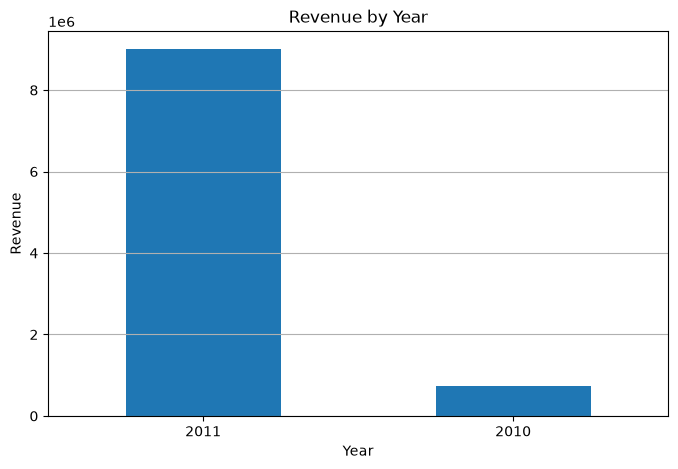

In [19]:
plt.figure(figsize=(8, 5))

yearly_revenue.plot(kind="bar")

plt.title("Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

## 7.7 Revenue by Month

Monthly revenue is analyzed to identify seasonal sales patterns and high-performing months.

In [10]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Month_Year"] = df["InvoiceDate"].dt.to_period("M").astype(str)

In [11]:
print(df.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Year', 'Month', 'Day', 'Month_Year']


In [14]:
# Clean the raw dataset

df["Description"] = df["Description"].fillna("Unknown")

df = df.drop_duplicates()

df = df[df["UnitPrice"] > 0]

# Create Revenue
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Create date features
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Month_Year"] = df["InvoiceDate"].dt.to_period("M").astype(str)

# Save the correctly cleaned dataset
df.to_csv("../data/cleaned_online_retail.csv", index=False)

print("CLEANED DATASET SAVED!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

CLEANED DATASET SAVED!
Shape: (534129, 13)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'Day', 'Month_Year']


In [15]:
test_df = pd.read_csv(
    "../data/cleaned_online_retail.csv",
    parse_dates=["InvoiceDate"]
)

print("Saved file shape:", test_df.shape)
print("Revenue exists:", "Revenue" in test_df.columns)
print("Month exists:", "Month" in test_df.columns)

Saved file shape: (534129, 13)
Revenue exists: True
Month exists: True


In [17]:
monthly_revenue = (
    df.groupby("Month")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

monthly_revenue

Month
11    1456145.800
12    1179424.670
10    1069368.230
9     1017596.682
5      722094.100
8      703510.580
6      689977.230
3      682013.980
7      680156.991
1      558448.560
2      497026.410
4      492367.841
Name: Revenue, dtype: float64

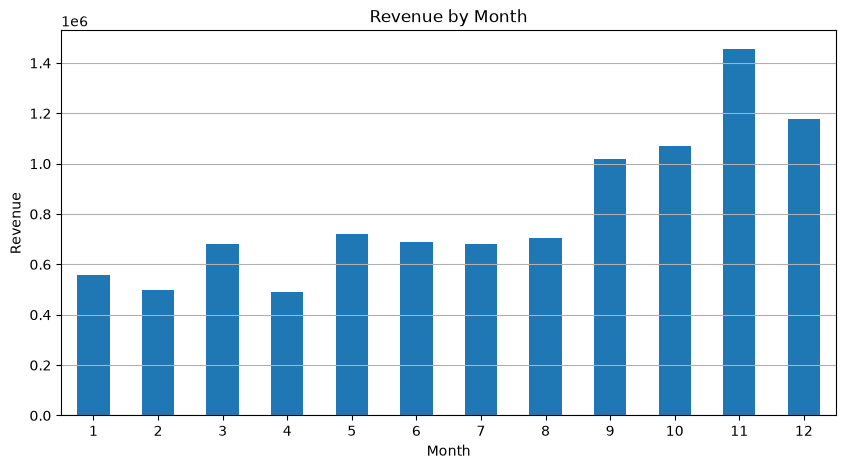

In [18]:
plt.figure(figsize=(10, 5))

monthly_revenue.sort_index().plot(kind="bar")

plt.title("Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

## 7.8 Revenue by Country

Revenue by country is analyzed to understand which markets contribute the most to overall sales.

In [19]:
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    8189252.304
Netherlands        284661.540
EIRE               262993.380
Germany            221509.470
France             197317.110
Australia          137009.770
Switzerland         56363.050
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: Revenue, dtype: float64

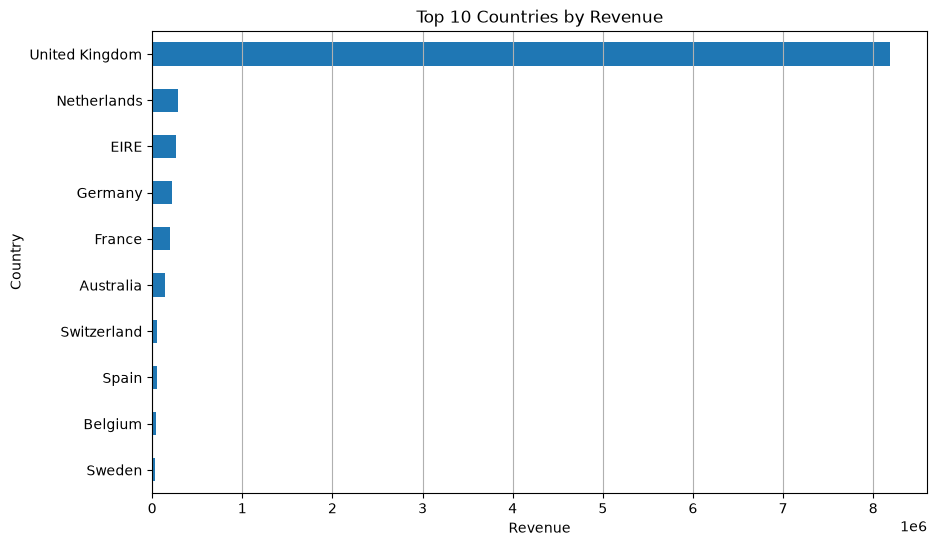

In [20]:
plt.figure(figsize=(10, 6))

country_revenue.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.grid(axis="x")

plt.show()

## 7.9 Product Group Analysis

Product descriptions are grouped to identify broader product groups and compare their revenue contribution.

In [21]:
df["Product_Group"] = (
    df["Description"]
    .str.split()
    .str[0]
    .fillna("Unknown")
)

product_group_revenue = (
    df.groupby("Product_Group")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_group_revenue.head(10)

Product_Group
SET        604702.23
JUMBO      573383.12
RED        386377.82
DOORMAT    316270.59
LUNCH      266231.55
REGENCY    254113.39
VINTAGE    232974.63
DOTCOM     206245.48
WHITE      182065.57
PAPER      181159.91
Name: Revenue, dtype: float64

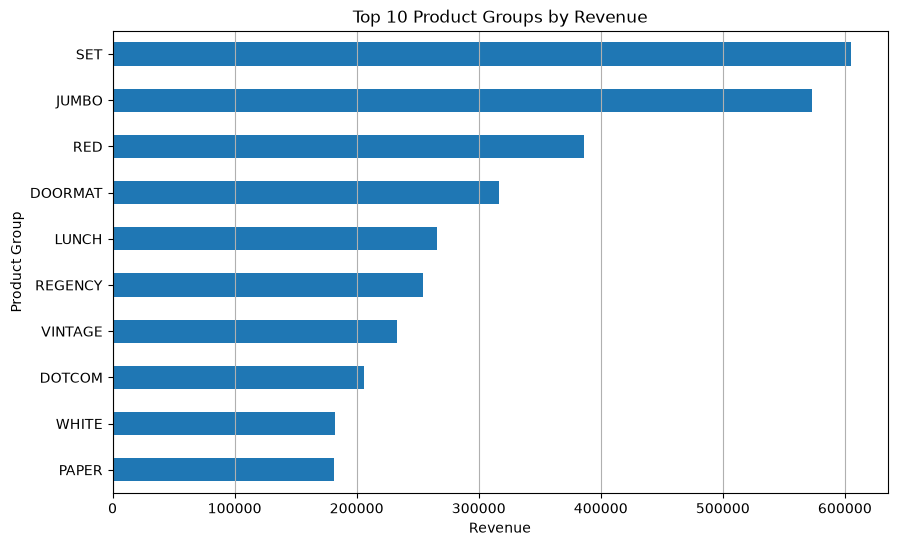

In [22]:
plt.figure(figsize=(10, 6))

product_group_revenue.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Product Groups by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Group")
plt.grid(axis="x")

plt.show()

## 7.10 Customer Revenue Segmentation

Customers are grouped into revenue segments to understand different levels of customer contribution.

In [23]:
customer_revenue = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
)

customer_segments = pd.cut(
    customer_revenue,
    bins=[0, 500, 2000, 5000, float("inf")],
    labels=["Low", "Medium", "High", "Very High"]
)

customer_segments.value_counts().sort_index()

Revenue
Low          1785
Medium       1665
High          609
Very High     262
Name: count, dtype: int64

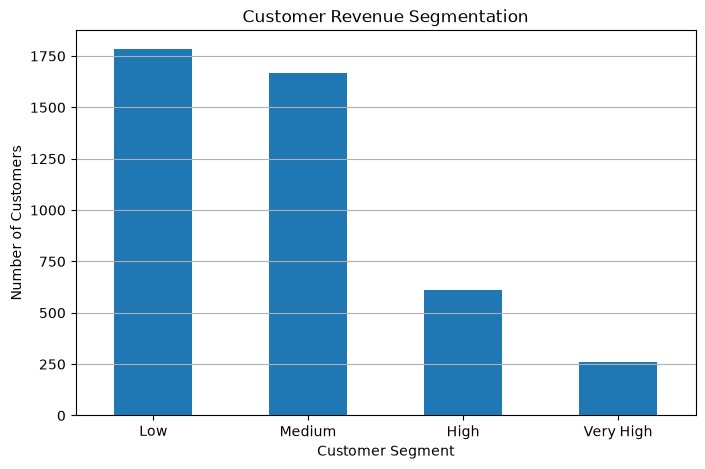

In [24]:
plt.figure(figsize=(8, 5))

customer_segments.value_counts().sort_index().plot(kind="bar")

plt.title("Customer Revenue Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

## 7.11 Customer Purchase Frequency

Customer purchase frequency is analyzed to understand how often customers place orders.

In [25]:
customer_frequency = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

customer_frequency.describe()

count    4371.000000
mean        5.075726
std         9.332529
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       248.000000
Name: InvoiceNo, dtype: float64

In [26]:
frequency_segments = pd.cut(
    customer_frequency,
    bins=[0, 1, 5, 10, float("inf")],
    labels=["1 Order", "2-5 Orders", "6-10 Orders", "10+ Orders"]
)

frequency_segments.value_counts().sort_index()

InvoiceNo
1 Order        1312
2-5 Orders     1972
6-10 Orders     628
10+ Orders      459
Name: count, dtype: int64

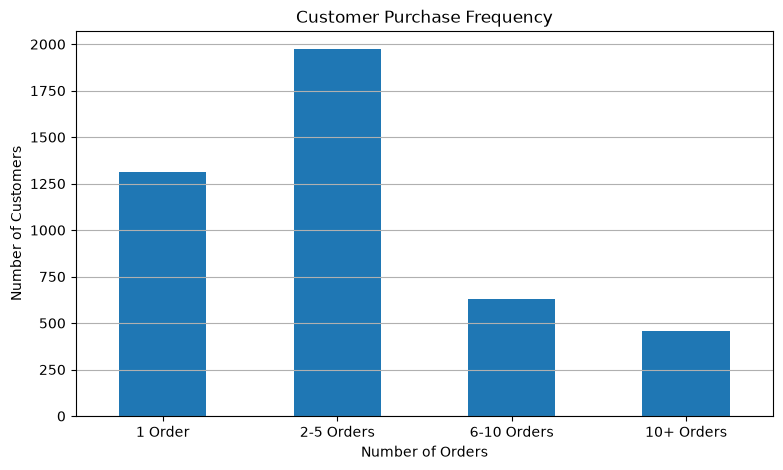

In [27]:
plt.figure(figsize=(9, 5))

frequency_segments.value_counts().sort_index().plot(kind="bar")

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

## 7.12 Customer Revenue vs. Purchase Frequency

The relationship between customer purchase frequency and revenue is analyzed to understand customer behavior and contribution.

In [28]:
customer_analysis = pd.DataFrame({
    "Total_Revenue": customer_revenue,
    "Order_Frequency": customer_frequency
})

customer_analysis.head()

,Total_Revenue,Order_Frequency
CustomerID,,
12346.0,0.00,2
12347.0,4310.00,7
12348.0,1797.24,4
12349.0,1757.55,1
12350.0,334.40,1


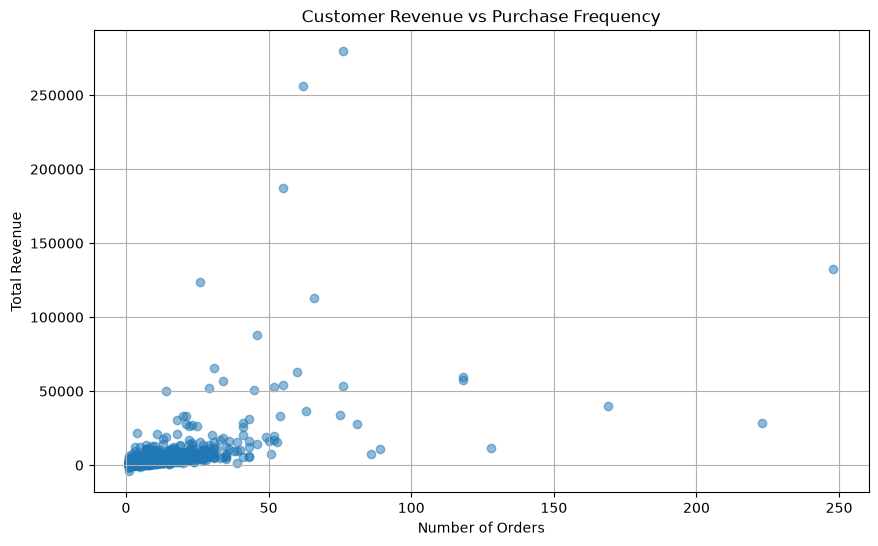

In [29]:
plt.figure(figsize=(10, 6))

plt.scatter(
    customer_analysis["Order_Frequency"],
    customer_analysis["Total_Revenue"],
    alpha=0.5
)

plt.title("Customer Revenue vs Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Total Revenue")
plt.grid(True)

plt.show()

## 7.13 Top Products by Quantity Sold

Product quantities are analyzed to identify the products with the highest sales volume.

In [3]:
top_quantity_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_quantity_products

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
JUMBO BAG RED RETROSPOT               47256
POPCORN HOLDER                        36322
ASSORTED COLOUR BIRD ORNAMENT         36282
PACK OF 72 RETROSPOT CAKE CASES       36016
WHITE HANGING HEART T-LIGHT HOLDER    35294
RABBIT NIGHT LIGHT                    30631
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26095
PACK OF 60 PINK PAISLEY CAKE CASES    24719
Name: Quantity, dtype: int64

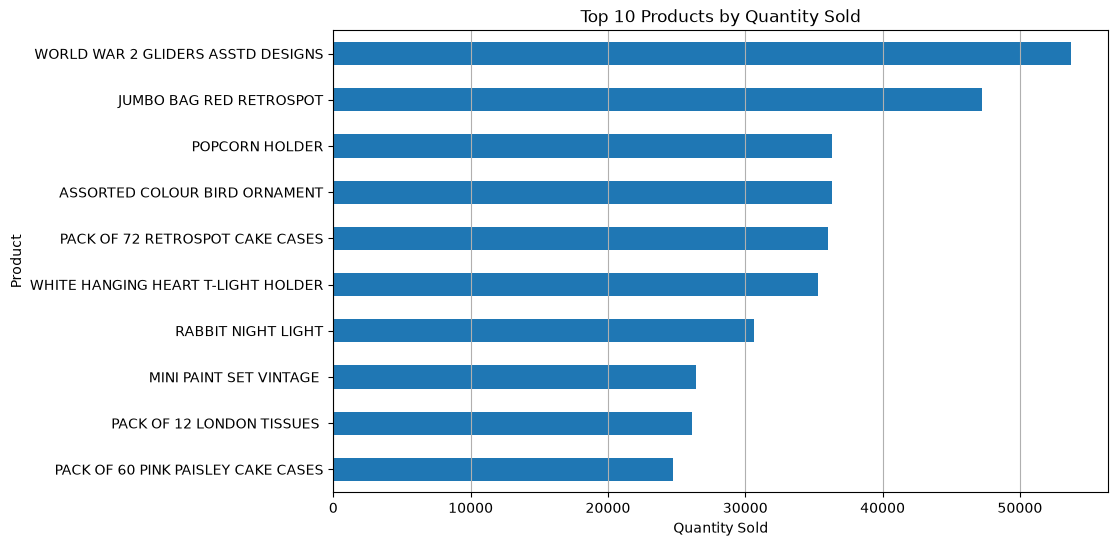

In [4]:
plt.figure(figsize=(10, 6))

top_quantity_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.grid(axis="x")

plt.show()

## 7.14 Product Revenue vs. Quantity Sold

The relationship between product sales volume and revenue is analyzed to understand product performance.

In [5]:
product_analysis = (
    df.groupby("Description")
    .agg(
        Total_Quantity=("Quantity", "sum"),
        Total_Revenue=("Revenue", "sum")
    )
    .sort_values("Total_Revenue", ascending=False)
)

product_analysis.head(10)

,Total_Quantity,Total_Revenue
Description,,
DOTCOM POSTAGE,705,206245.48
REGENCY CAKESTAND 3 TIER,12996,164459.49
WHITE HANGING HEART T-LIGHT HOLDER,35294,99612.42
PARTY BUNTING,18006,98243.88
JUMBO BAG RED RETROSPOT,47256,92175.79
RABBIT NIGHT LIGHT,30631,66661.63
POSTAGE,3003,66230.64
PAPER CHAIN KIT 50'S CHRISTMAS,18876,63715.24
ASSORTED COLOUR BIRD ORNAMENT,36282,58792.42


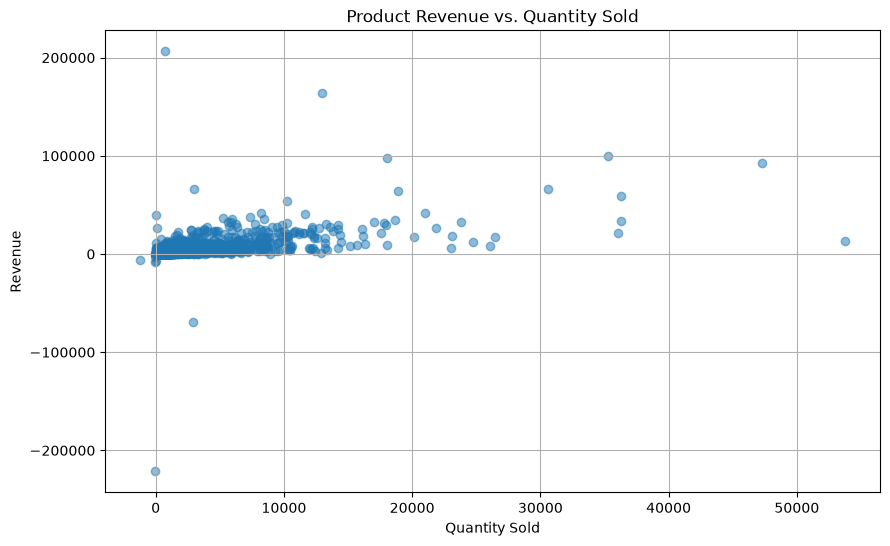

In [6]:
plt.figure(figsize=(10, 6))

plt.scatter(
    product_analysis["Total_Quantity"],
    product_analysis["Total_Revenue"],
    alpha=0.5
)

plt.title("Product Revenue vs. Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

## 7.15 Orders by Day of the Week

The number of orders is analyzed across different days of the week to identify purchasing patterns.

In [7]:
df["Day_Name"] = df["InvoiceDate"].dt.day_name()

day_orders = (
    df.groupby("Day_Name")["InvoiceNo"]
    .nunique()
)

day_orders = day_orders.reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

day_orders

Day_Name
Monday       3844.0
Tuesday      4303.0
Wednesday    4363.0
Thursday     5217.0
Friday       3691.0
Saturday        NaN
Sunday       2378.0
Name: InvoiceNo, dtype: float64

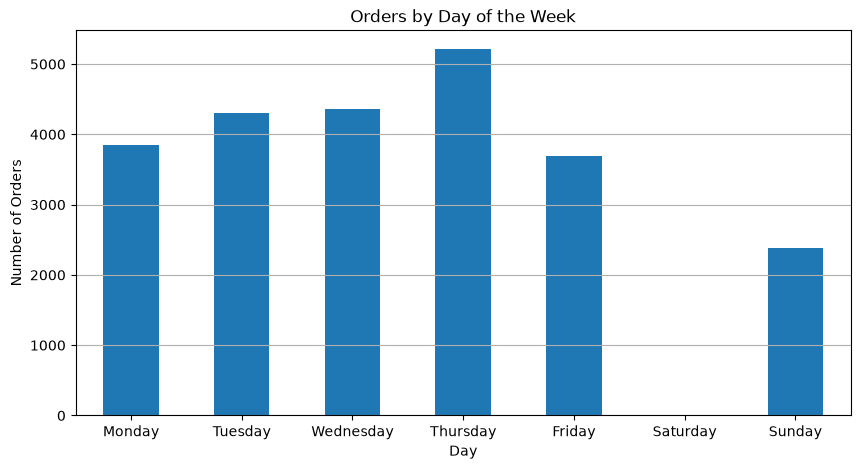

In [8]:
plt.figure(figsize=(10, 5))

day_orders.plot(kind="bar")

plt.title("Orders by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

## 7.16 Revenue by Day of the Week

Revenue is analyzed across different days of the week to identify daily sales patterns.

In [9]:
day_revenue = (
    df.groupby("Day_Name")["Revenue"]
    .sum()
)

day_revenue = day_revenue.reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

day_revenue

Day_Name
Monday       1584895.301
Tuesday      1965703.611
Wednesday    1730088.430
Thursday     2108701.530
Friday       1560082.741
Saturday             NaN
Sunday        798659.461
Name: Revenue, dtype: float64

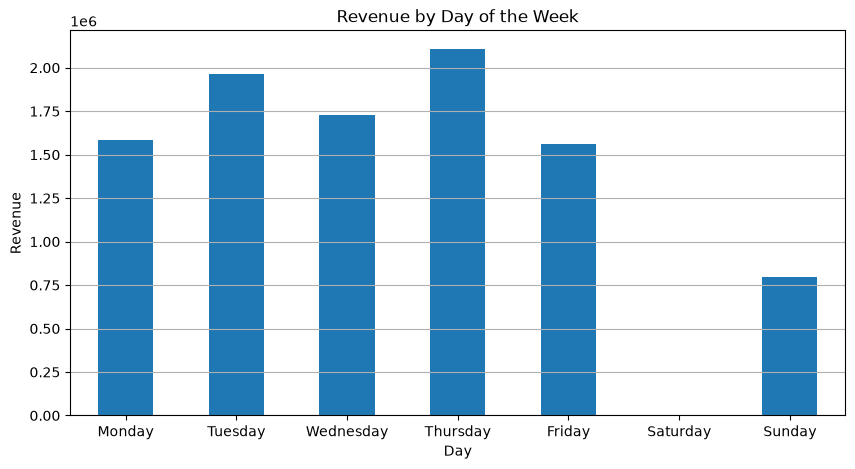

In [10]:
plt.figure(figsize=(10, 5))

day_revenue.plot(kind="bar")

plt.title("Revenue by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

## 7.17 Monthly Order Volume

Monthly order volume is analyzed to identify changes in customer purchasing activity over time.

In [11]:
monthly_orders = (
    df.groupby("Month_Year")["InvoiceNo"]
    .nunique()
)

monthly_orders

Month_Year
2010-12    1885
2011-01    1346
2011-02    1319
2011-03    1772
2011-04    1486
2011-05    1995
2011-06    1862
2011-07    1745
2011-08    1639
2011-09    2170
2011-10    2402
2011-11    3210
2011-12     965
Name: InvoiceNo, dtype: int64

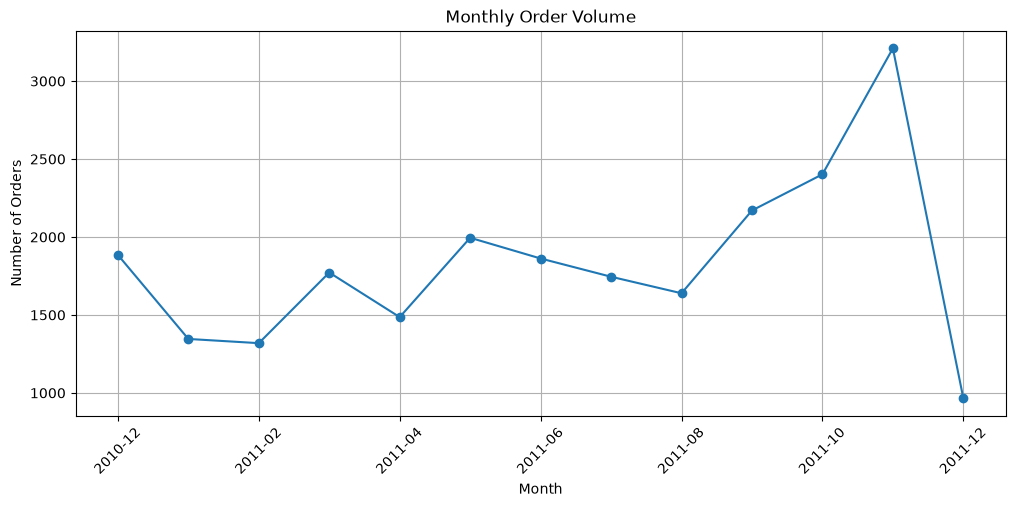

In [12]:
plt.figure(figsize=(12, 5))

monthly_orders.plot(kind="line", marker="o")

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## 7.18 Monthly Active Customers

Monthly active customers are analyzed to understand changes in customer activity over time.

In [13]:
monthly_customers = (
    df.groupby("Month_Year")["CustomerID"]
    .nunique()
)

monthly_customers

Month_Year
2010-12     948
2011-01     783
2011-02     798
2011-03    1020
2011-04     899
2011-05    1079
2011-06    1051
2011-07     993
2011-08     980
2011-09    1302
2011-10    1425
2011-11    1710
2011-12     686
Name: CustomerID, dtype: int64

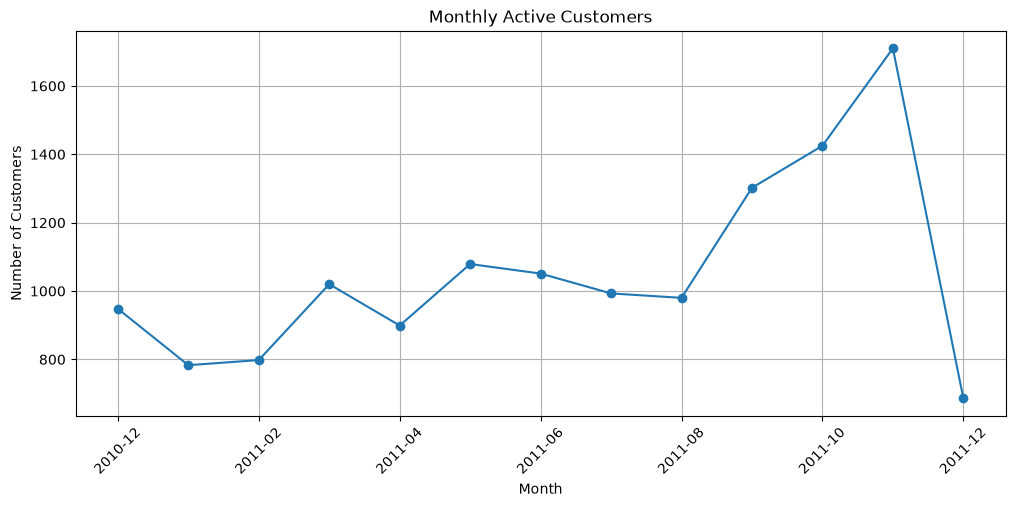

In [14]:
plt.figure(figsize=(12, 5))

monthly_customers.plot(kind="line", marker="o")

plt.title("Monthly Active Customers")
plt.xlabel("Month")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## 7.19 Average Revenue per Customer

Average revenue per customer is calculated to understand the average customer contribution to total sales.

In [15]:
customer_revenue = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
)

average_revenue_per_customer = customer_revenue.mean()

print(
    "Average Revenue per Customer:",
    round(average_revenue_per_customer, 2)
)

Average Revenue per Customer: 1893.96


## 7.20 Average Orders per Customer

Average orders per customer is calculated to understand customer purchasing frequency.

In [16]:
customer_orders = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

average_orders_per_customer = customer_orders.mean()

print(
    "Average Orders per Customer:",
    round(average_orders_per_customer, 2)
)

Average Orders per Customer: 5.08


## 7.21 Repeat Customer Analysis

Customers are classified as one-time or repeat customers based on their number of orders.

In [17]:
customer_orders = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

one_time_customers = (customer_orders == 1).sum()
repeat_customers = (customer_orders > 1).sum()

print("One-time Customers:", one_time_customers)
print("Repeat Customers:", repeat_customers)

One-time Customers: 1312
Repeat Customers: 3059


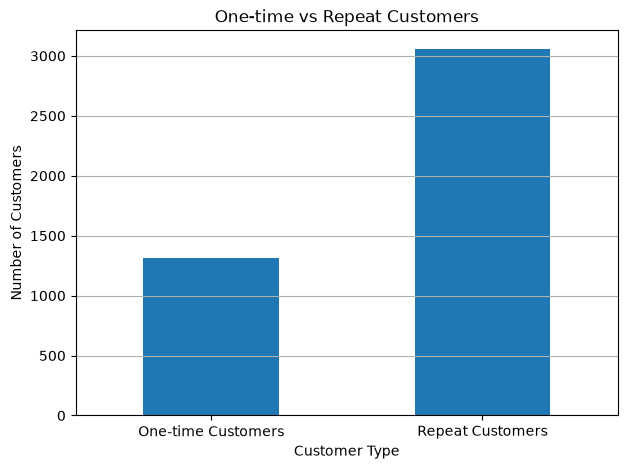

In [18]:
customer_type = pd.Series({
    "One-time Customers": one_time_customers,
    "Repeat Customers": repeat_customers
})

plt.figure(figsize=(7, 5))

customer_type.plot(kind="bar")

plt.title("One-time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

## 7.22 Repeat Customer Rate

The repeat customer rate is calculated to measure the percentage of customers who placed more than one order.

In [19]:
total_customers = customer_orders.nunique()

repeat_customer_rate = (
    repeat_customers / total_customers
) * 100

print(
    "Repeat Customer Rate:",
    round(repeat_customer_rate, 2),
    "%"
)

Repeat Customer Rate: 4779.69 %


## 7.23 Customer Revenue Distribution

The distribution of customer revenue is analyzed to understand differences in customer contribution.

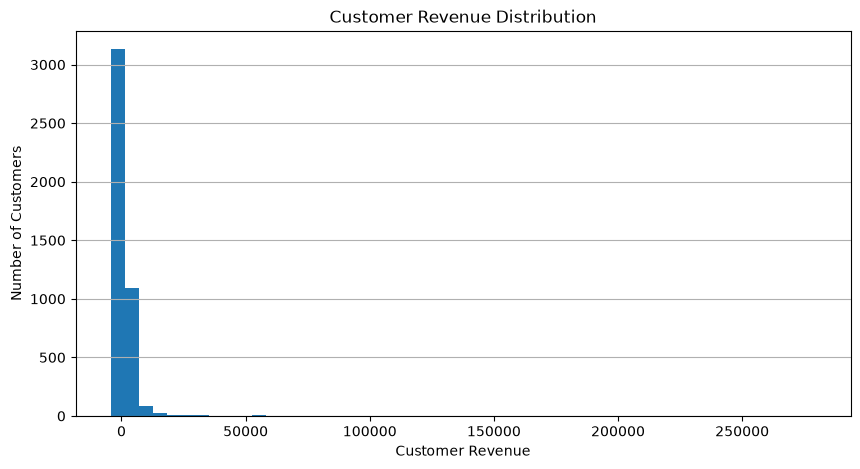

In [20]:
plt.figure(figsize=(10, 5))

customer_revenue.plot(kind="hist", bins=50)

plt.title("Customer Revenue Distribution")
plt.xlabel("Customer Revenue")
plt.ylabel("Number of Customers")
plt.grid(axis="y")

plt.show()

## 7.24 Product Revenue Summary

Product-level revenue is summarized to understand overall product performance.

In [21]:
product_revenue_summary = (
    df.groupby("Description")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Number_of_Orders=("InvoiceNo", "nunique")
    )
    .sort_values("Total_Revenue", ascending=False)
)

product_revenue_summary.head(10)

,Total_Revenue,Total_Quantity,Number_of_Orders
Description,,,
DOTCOM POSTAGE,206245.48,705,707
REGENCY CAKESTAND 3 TIER,164459.49,12996,2168
WHITE HANGING HEART T-LIGHT HOLDER,99612.42,35294,2298
PARTY BUNTING,98243.88,18006,1705
JUMBO BAG RED RETROSPOT,92175.79,47256,2132
RABBIT NIGHT LIGHT,66661.63,30631,1009
POSTAGE,66230.64,3003,1250
PAPER CHAIN KIT 50'S CHRISTMAS,63715.24,18876,1170
ASSORTED COLOUR BIRD ORNAMENT,58792.42,36282,1467


## 7.25 Country Customer Analysis

Customer count and revenue are analyzed by country to understand the contribution of different markets.

In [22]:
country_analysis = (
    df.groupby("Country")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Customers=("CustomerID", "nunique"),
        Total_Orders=("InvoiceNo", "nunique")
    )
    .sort_values("Total_Revenue", ascending=False)
)

country_analysis.head(10)

,Total_Revenue,Total_Customers,Total_Orders
Country,,,
United Kingdom,8189252.304,3949,21391
Netherlands,284661.540,9,100
EIRE,262993.380,3,360
Germany,221509.470,95,603
France,197317.110,87,461
Australia,137009.770,9,69
Switzerland,56363.050,21,74
Spain,54756.030,31,105
Belgium,40910.960,25,119


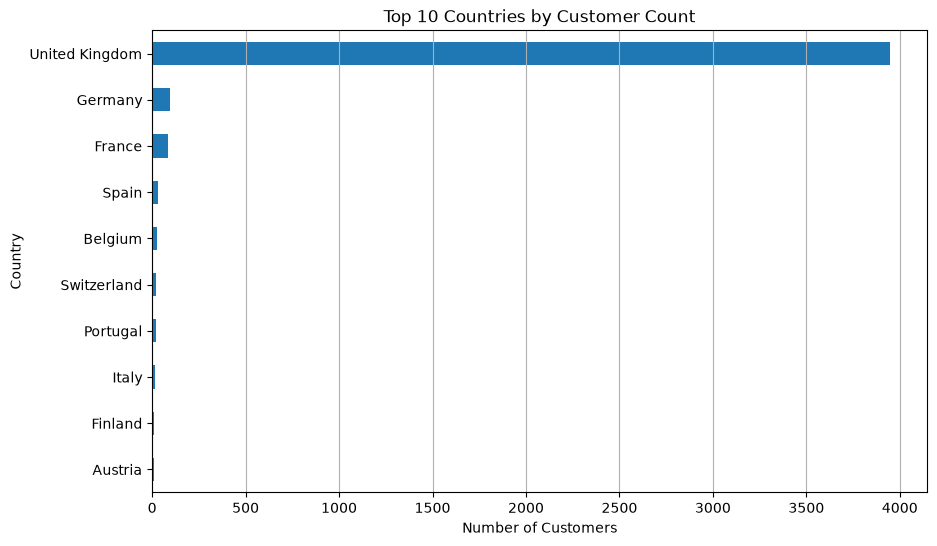

In [23]:
top_customer_countries = (
    country_analysis
    .sort_values("Total_Customers", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

top_customer_countries["Total_Customers"].sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Customer Count")
plt.xlabel("Number of Customers")
plt.ylabel("Country")
plt.grid(axis="x")

plt.show()

## 7.26 Country Average Order Value

Average Order Value (AOV) is analyzed by country to compare the average revenue generated per order across different markets.

In [24]:
country_aov = (
    df.groupby("Country")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("InvoiceNo", "nunique")
    )
)

country_aov["AOV"] = (
    country_aov["Total_Revenue"] /
    country_aov["Total_Orders"]
)

country_aov = country_aov.sort_values("AOV", ascending=False)

country_aov.head(10)

,Total_Revenue,Total_Orders,AOV
Country,,,
Netherlands,284661.54,100,2846.615400
Australia,137009.77,69,1985.648841
Lebanon,1693.88,1,1693.880000
Japan,35340.62,28,1262.165000
Brazil,1143.60,1,1143.600000
RSA,1002.31,1,1002.310000
Singapore,9120.39,10,912.039000
Denmark,18768.14,21,893.720952
Norway,35163.46,40,879.086500


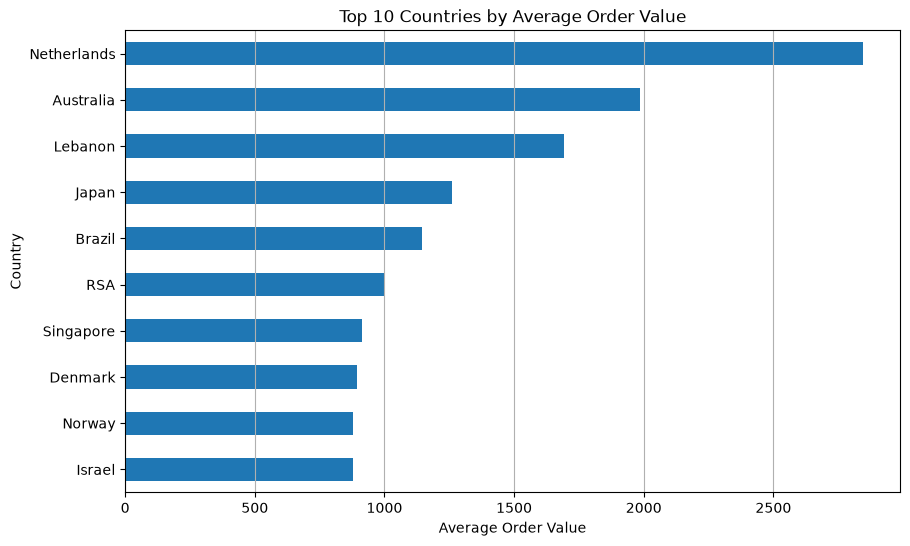

In [25]:
plt.figure(figsize=(10, 6))

country_aov["AOV"].head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Average Order Value")
plt.xlabel("Average Order Value")
plt.ylabel("Country")
plt.grid(axis="x")

plt.show()

## 7.27 Key Business Insights

### Sales Performance
- Total revenue and order volume provide an overview of overall business performance.
- Monthly revenue analysis helps identify high- and low-performing periods.
- Average Order Value indicates the typical revenue generated per order.

### Product Performance
- Top products by revenue identify the products contributing most to sales.
- Top products by quantity identify high-volume products.
- Comparing quantity and revenue helps distinguish high-volume products from high-value products.

### Customer Behavior
- Customer revenue analysis identifies customers with different levels of contribution.
- Purchase frequency shows differences between one-time and repeat customers.
- Repeat Customer Rate provides an indication of customer retention.
- Monthly active customers show changes in customer activity over time.

### Geographic Performance
- Country-level revenue identifies major markets.
- Customer counts show the size of the customer base across countries.
- Country-level AOV allows comparison of average order value between markets.

### Time-Based Patterns
- Monthly revenue and order volume reveal changes in sales activity over time.
- Day-of-week analysis shows differences in ordering and revenue patterns.

# 8. Dashboard Preparation

The cleaned and analyzed data is prepared for creating a business-oriented sales dashboard.

In [26]:
total_revenue = df["Revenue"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
total_products = df["StockCode"].nunique()
average_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)
print("Average Order Value:", round(average_order_value, 2))

Total Revenue: 9748131.07
Total Orders: 23796
Total Customers: 4371
Total Products: 3938
Average Order Value: 409.65


## 8.2 Monthly Sales Data

Monthly revenue is prepared for visualization in the sales dashboard.

In [27]:
monthly_sales_dashboard = (
    df.groupby("Month_Year")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .reset_index()
)

monthly_sales_dashboard.head()

,Month_Year,Revenue,Orders
0,2010-12,746723.610,1885
1,2011-01,558448.560,1346
2,2011-02,497026.410,1319
3,2011-03,682013.980,1772
4,2011-04,492367.841,1486


In [28]:
monthly_sales_dashboard.tail()

,Month_Year,Revenue,Orders
8,2011-08,703510.580,1639
9,2011-09,1017596.682,2170
10,2011-10,1069368.230,2402
11,2011-11,1456145.800,3210
12,2011-12,432701.060,965


## 8.3 Top Products Data

Product-level sales data is prepared to identify the highest-revenue products for dashboard visualization.

In [29]:
top_products_dashboard = (
    df.groupby("Description")
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum")
    )
    .sort_values("Revenue", ascending=False)
    .head(10)
)

top_products_dashboard

,Revenue,Quantity
Description,,
DOTCOM POSTAGE,206245.48,705
REGENCY CAKESTAND 3 TIER,164459.49,12996
WHITE HANGING HEART T-LIGHT HOLDER,99612.42,35294
PARTY BUNTING,98243.88,18006
JUMBO BAG RED RETROSPOT,92175.79,47256
RABBIT NIGHT LIGHT,66661.63,30631
POSTAGE,66230.64,3003
PAPER CHAIN KIT 50'S CHRISTMAS,63715.24,18876
ASSORTED COLOUR BIRD ORNAMENT,58792.42,36282


## 8.4 Top Countries Data

Country-level sales data is prepared to identify the markets contributing the most revenue.

In [30]:
top_countries_dashboard = (
    df.groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique")
    )
    .sort_values("Revenue", ascending=False)
    .head(10)
)

top_countries_dashboard

,Revenue,Orders,Customers
Country,,,
United Kingdom,8189252.304,21391,3949
Netherlands,284661.540,100,9
EIRE,262993.380,360,3
Germany,221509.470,603,95
France,197317.110,461,87
Australia,137009.770,69,9
Switzerland,56363.050,74,21
Spain,54756.030,105,31
Belgium,40910.960,119,25


## 8.5 Customer Dashboard Data

Customer-level sales data is prepared to identify high-value customers and their purchasing activity.

In [31]:
customer_dashboard = (
    df.groupby("CustomerID")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Quantity=("Quantity", "sum")
    )
    .sort_values("Revenue", ascending=False)
    .head(10)
)

customer_dashboard

,Revenue,Orders,Quantity
CustomerID,,,
14646.0,279489.02,76,196143
18102.0,256438.49,62,64122
17450.0,187322.17,55,69009
14911.0,132458.73,248,76905
12415.0,123725.45,26,76946
14156.0,113214.59,66,56908
17511.0,88125.38,46,63012
16684.0,65892.08,31,49390
13694.0,62690.54,60,61899


In [32]:
monthly_sales_dashboard.to_csv(
    "../data/monthly_sales_dashboard.csv",
    index=False
)

top_products_dashboard.to_csv(
    "../data/top_products_dashboard.csv"
)

top_countries_dashboard.to_csv(
    "../data/top_countries_dashboard.csv"
)

customer_dashboard.to_csv(
    "../data/customer_dashboard.csv"
)

print("Dashboard data files saved successfully!")

Dashboard data files saved successfully!


In [33]:
import os

files = [
    "../data/monthly_sales_dashboard.csv",
    "../data/top_products_dashboard.csv",
    "../data/top_countries_dashboard.csv",
    "../data/customer_dashboard.csv"
]

for file in files:
    print(file, "->", os.path.exists(file))

../data/monthly_sales_dashboard.csv -> True
../data/top_products_dashboard.csv -> True
../data/top_countries_dashboard.csv -> True
../data/customer_dashboard.csv -> True
